# **PREPROCESAMIENTO DE TEXTOS**

## **PARA REPRESENTACIONES TRADICIONALES (TF-IDF / BoW)**

Cargamos las librerías que usaremos en el preprocesamiento y fijamos configuración básica (paths, semilla, warnings). Priorizamos dependencias ligeras (regex, pandas) y spaCy para la parte lingüística. Esto nos permite reproducibilidad y un entorno limpio.

In [4]:
import re
import pandas as pd
from tqdm import tqdm
import spacy

df = pd.read_csv("../../data/definitivos/INDEX_ALL_scrapped_filtrado.csv")

Lo primero es limpiar símbolos y distintas cosas que el modelo pueda malinterpretar. Observando los textos de los articulos, hemos detectado que se cuelan algunos simbolos como ">" "<" o comillas,...Hemos tomado la decisión de eliminarlas para un mejor funcionamiento

In [5]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "textcat","ner"])
tqdm.pandas()

Vamos a definir KEEP_TERMS (acró-nimos y términos clave: UK, ONS, GDP, etc.) y un patrón para acrónimos (ACRONYM_RE) para proteger señales del dominio que spaCy podría lematizar o filtrar por error. Con esto preservamos vocabulario financiero crítico.

In [6]:
STOPWORDS = set(nlp.Defaults.stop_words)
STOPWORDS.discard("us")
STOPWORDS.discard("on")

KEEP_TERMS = {
    "uk", "us", "eu", "hk", "jp", "cn", "in", "br", "mx", "de", "fr", "it", "sg", "za", "kr",
    "ceo", "cfo", "coo", "cto", "cio",
    "ipo", "esg", "gdp", "cpi", "pmi", "ppi", "eps", "roi", "ebitda", "ev",
    "fx", "irr", "yoy", "qoq", "bps", "roe", "roa", "nav",
    "ai", "ml", "iot", "api", "saas", "b2b", "b2c",
    "nyse", "nasdaq", "ftse", "dax", "cac", "nikkei", "tsx",
    "ons", "imf", "oecd", "ecb", "boe", "fed", "sec", "bis", "opec", "wto", "un",
    "fca", "frc", "fsb","gm", "ge", "bp", "ibm", "aapl", "tsla", "msft", "meta", "googl", "amzn",
}
PLACEHOLDER_RE = re.compile(r"__\w+__")
ACRONYM_RE = re.compile(r"^[A-Z]{2,6}$")           # Para detectar: UK, ONS, GDP, NASDAQ,...Que son entidades relevantes y que aparecen en bastantes noticias
MIXED_CASE_RE = re.compile(r"^[A-Z0-9&]+$")        # Lo mismo pero con terminos como: S&P, AT&T, 5G

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
BOILERPLATE_RE = re.compile(
    r"(^read more:.*$|^story continues.*$|copyright\s*©.*$)",
    flags=re.IGNORECASE | re.MULTILINE,
)
CASHTAG_RE = re.compile(r"\$([A-Za-z]{1,10})\b")

Compilamos patrones para sustituir __PERCENT__, __MONEY__, __YEAR__, __TICKER__, etc. En noticias financieras estas entidades tienen alta variabilidad y disparan el vocabulario; los placeholders estabilizan el espacio y bajan la sparsity. Mantenemos la categoría semántica sin perder señal informativa.

In [7]:
def pre_rules(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # 1. Normalizar caracteres especiales
    text = (text.replace("'", "'").replace(""", '"').replace(""", '"')
                 .replace("–", "-").replace("—", "-"))
    
    # 2. Limpiar cosas que se nos han podido colar al hacer scraping, HTML y URLs
    t = BOILERPLATE_RE.sub("", text)
    t = HTML_TAG_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = re.sub(r'[<>]', ' ', t)
    
    # 4. PLACEHOLDERS ANTES DE LOWERCASE (para detectar mayúsculas)
    t = re.sub(CASHTAG_RE, "__TICKER__", t)
    
    # Trimestres (Q1, Q2, etc.)
    t = re.sub(r'\bQ([1-4])\b', r'__QTR\1__', t, flags=re.IGNORECASE)
    
    # Formato: "Jan 15", "15 January", etc.
    t = re.sub(r'\b((jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)[a-z]*\s+\d{1,2})\b',
               '__DATE__', t, flags=re.IGNORECASE)
    t = re.sub(r'\b(\d{1,2}\s+(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)[a-z]*)\b',
               '__DATE__', t, flags=re.IGNORECASE)
    
    # Años (1900-2099)
    t = re.sub(r'\b(19|20)\d{2}\b', '__YEAR__', t)
    
    # Porcentajes
    t = re.sub(r'\b[+-]?\d[\d,\.]*\s*%(?=\W|$)', '__PERCENT__', t)
    t = re.sub(r'\b[+-]?\d[\d,\.]*\s*percent(?=\W|$)', '__PERCENT__', t, flags=re.IGNORECASE)
    t = re.sub(r'\b[+-]?\d[\d,\.]*\s*per\s+cent(?=\W|$)', '__PERCENT__', t, flags=re.IGNORECASE)
    
    # Dinero ($100, €50, £20, $5M, etc.)
    t = re.sub(r'[\$€£]\s*\d[\d,\.]*\s*(?:bn|b|m|k|million|billion|trillion)?\b', 
               '__MONEY__', t, flags=re.IGNORECASE)
    
    # Cantidades grandes (100 million, 5 billion, etc.)
    t = re.sub(r'\b\d[\d,\.]*\s*(million|billion|trillion|bn|m)\b', 
               '__AMOUNT__', t, flags=re.IGNORECASE)
    
    # 5. AHORA SÍ: convertir a minúsculas
    t = t.lower()
    
    # 6. Números genéricos
    t = re.sub(r'(?<![a-z_])\b\d[\d,\.]*\b(?![a-z_])', '__NUM__', t)
    
    # 7. Limpiar caracteres no deseados (después de placeholders)
    t = re.sub(r'[^a-z0-9\s.,?!\'\"-_]+', ' ', t)
    
    # 8. Normalizar espacios
    t = re.sub(r'\s+', ' ', t).strip()
    
    return t

### Problema que nos ha surgido: 

Acronimos, bolsas como el S&P,...Se eliminaban de los textos porque teniamos mal hecho un filtro al lemmatizar. Para esto hemos tratado de resolver introducioendo una variable KEEP_TERMS con terminos relevanates que hemos visto por las noticias, así como ACRONYM_RE para casos como COS o los que no hayamos metido en la lista

Implementamos la segunda fase: lematización + filtrado selectivo. Quitamos stopwords y tokens no alfabéticos salvo excepciones protegidas, y aplicamos reglas sobre longitud mínima. El objetivo es quedarnos con contenido semántico útil y estable.

In [8]:
def spacy_clean_strong(doc) -> str:
    out = []
    
    for tok in doc:
        text_tok = tok.text 
        text_lower = text_tok.lower()
        lemma = tok.lemma_.lower()
        
        # 1. PRESERVAR PLACEHOLDERS (siempre van primero)
        if PLACEHOLDER_RE.match(text_tok):
            out.append(text_tok)
            continue
        
        # 2. SALTAR PUNTUACIÓN Y ESPACIOS
        if tok.is_punct or tok.is_space:
            continue
        
        # 3. PRESERVAR TÉRMINOS IMPORTANTES
        if text_lower in KEEP_TERMS or lemma in KEEP_TERMS:
            out.append(text_lower)
            continue
        
        # 4. DETECTAR ACRÓNIMOS POR PATRÓN(captura los términos que no hemos visto en las noticias, por si nos hemos dejado alguno)
        # Esto captura ONS, GDP, S&P, etc. que no estén en KEEP_TERMS
        if ACRONYM_RE.match(text_tok) or MIXED_CASE_RE.match(text_tok):
            out.append(text_lower)
            continue
        
        # 5. FILTRAR STOPWORDS (usando el LEMMA)
        if lemma in STOPWORDS:
            continue
        
        # 6. PALABRAS NORMALES (solo alfabéticas, ≥3 caracteres)
        if lemma.isalpha() and len(lemma) >= 3:
            out.append(lemma)
            continue
    
    return " ".join(out)



In [9]:
def preprocess_text_for_nc_embeddings(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Paso 1: Normalización y placeholders
    text_normalized = pre_rules(text)
    
    # Paso 2: Procesamiento con spaCy
    doc = nlp(text_normalized)
    text_clean = spacy_clean_strong(doc)
    
    return text_clean

In [10]:
def analyze_preprocessing(original_text: str, show_tokens: int = 50):

    print("TEXTO ORIGINAL:")
    print(original_text[:200] + "..." if len(original_text) > 200 else original_text)
    print()
    
    normalized = pre_rules(original_text)
    print("DESPUÉS DE pre_rules():")
    print(normalized[:200] + "..." if len(normalized) > 200 else normalized)
    print()
    
    doc = nlp(normalized)
    
    print("ANÁLISIS TOKEN POR TOKEN (primeros", show_tokens, "tokens):")
    print(f"{'TOKEN':<15} {'LEMMA':<15} {'POS':<8} {'¿MANTENER?':<12} {'RAZÓN'}")
    print("-" * 80)
    
    kept_tokens = []
    for i, tok in enumerate(doc):
        if i >= show_tokens:
            break
            
        text_tok = tok.text
        text_lower = text_tok.lower()
        lemma = tok.lemma_.lower()
        pos = tok.pos_
        
        if PLACEHOLDER_RE.match(text_tok):
            kept_tokens.append(text_tok)
            mantener, razon = "SÍ", "Placeholder"
        elif tok.is_punct or tok.is_space:
            mantener, razon = "NO", "Puntuación/Espacio"
        elif text_lower in KEEP_TERMS or lemma in KEEP_TERMS:
            kept_tokens.append(text_lower)
            mantener, razon = "SÍ", "KEEP_TERMS"
        elif ACRONYM_RE.match(text_tok) or MIXED_CASE_RE.match(text_tok):
            kept_tokens.append(text_lower)
            mantener, razon = "SÍ", "Acrónimo (patrón)"
        elif lemma in STOPWORDS:
            mantener, razon = "NO", "Stopword"
        elif lemma.isalpha() and len(lemma) >= 3:
            kept_tokens.append(lemma)
            mantener, razon = "SÍ", "Palabra válida"
        else:
            mantener, razon = "NO", "Muy corta/no alfabética"
        
        print(f"{text_tok:<15} {lemma:<15} {pos:<8} {mantener:<12} {razon}")
    
    print()
    print(f"TOKENS ORIGINALES: {len(doc)}")
    print(f"TOKENS MANTENIDOS: {len(kept_tokens)}")
    print(f"REDUCCIÓN: {100 * (1 - len(kept_tokens)/len(doc)):.1f}%")
    print()
    
    final = spacy_clean_strong(doc)
    
    return final

In [ ]:
df["noContextText"] = df["article_text"].progress_apply(preprocess_text_for_nc_embeddings)

print("\nfin")
print(f"Filas procesadas: {len(df)}")
print(f"Textos válidos: {df['noContextText'].notna().sum()}")
print(f"Textos vacíos: {(df['noContextText'].str.len() == 0).sum()}\n")

Iniciando preprocesamiento del dataset...
Total de filas: 5160



100%|██████████| 5160/5160 [03:46<00:00, 22.81it/s]


fin
Filas procesadas: 5160
Textos válidos: 5160
Textos vacíos: 0



## **ANALISIS DE LOS RESULTADOS**

### MUESTRAS DE LOS FILTROS APLICADOS

In [26]:

mask_valid = df["article_text"].notna() & (df["article_text"].astype(str).str.len() > 30)
primera_fila = df[mask_valid].iloc[0]
texto_original = str(primera_fila["article_text"])

analyze_preprocessing(texto_original, show_tokens=60)

df_valid = df[df["noContextText"].str.len() > 0].copy()
df_valid["original_words"] = df_valid["article_text"].str.split().str.len()
df_valid["processed_words"] = df_valid["noContextText"].str.split().str.len()
df_valid["reduction_pct"] = 100 * (1 - df_valid["processed_words"] / df_valid["original_words"])


TEXTO ORIGINAL:
The UK jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month.
The latest data from the Office for National Stat...

DESPUÉS DE pre_rules():
the uk jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month. the latest data from the office for national stati...

ANÁLISIS TOKEN POR TOKEN (primeros 60 tokens):
TOKEN           LEMMA           POS      ¿MANTENER?   RAZÓN
--------------------------------------------------------------------------------
the             the             DET      NO           Stopword
uk              uk              PROPN    SÍ           KEEP_TERMS
jobs            job             NOUN     SÍ           Palabra válida
market          market          NOUN     SÍ           Palabra válida
continues       continue        VERB     SÍ           Palabra válida
to              to          

Inspeccionamos una noticia “antes/después” para validar decisiones de filtrado. Queremos ver stopwords fuera y términos financieros dentro (p. ej., market, growth, weakness), y placeholders respetados. Es una verificación cualitativa del pipeline. Podemos ver con esto que los filtros están funcionando correctamente.

### PLOTS EXPLICATIVOS DE LOS RESULTADOS

In [27]:
print(f"\nPalabras originales (promedio): {df_valid['original_words'].mean():.1f}")
print(f"Palabras procesadas (promedio): {df_valid['processed_words'].mean():.1f}")
print(f"Reducción promedio: {df_valid['reduction_pct'].mean():.1f}%")
print(f"\nPalabras originales (mediana): {df_valid['original_words'].median():.1f}")
print(f"Palabras procesadas (mediana): {df_valid['processed_words'].median():.1f}")
print(f"Reducción mediana: {df_valid['reduction_pct'].median():.1f}%")


Palabras originales (promedio): 426.9
Palabras procesadas (promedio): 253.6
Reducción promedio: 38.9%

Palabras originales (mediana): 404.0
Palabras procesadas (mediana): 245.0
Reducción mediana: 39.1%


Resumimos visualmente la reducción de longitud con barras (media/mediana). Este gráfico comunica de un vistazo el impacto del preprocesamiento. Complementa a la distribución y facilita citar cifras en el report.

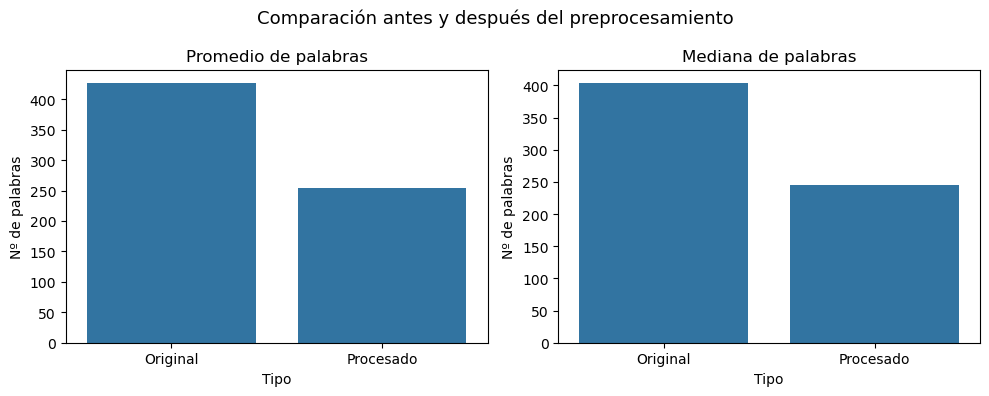

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

summary = pd.DataFrame({
    'Tipo': ['Original', 'Procesado'],
    'Media': [
        df_valid['original_words'].mean(),
        df_valid['processed_words'].mean()
    ],
    'Mediana': [
        df_valid['original_words'].median(),
        df_valid['processed_words'].median()
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.barplot(x='Tipo', y='Media', data=summary, ax=axes[0])
axes[0].set_title('Promedio de palabras')
axes[0].set_ylabel('Nº de palabras')

sns.barplot(x='Tipo', y='Mediana', data=summary, ax=axes[1])
axes[1].set_title('Mediana de palabras')
axes[1].set_ylabel('Nº de palabras')

plt.suptitle('Comparación antes y después del preprocesamiento', fontsize=13)
plt.tight_layout()
plt.show()



Mostramos el histograma de longitudes antes/después. Esperamos un desplazamiento de la distribución hacia la izquierda manteniendo la forma general, señal de que quitamos ruido sin vaciar el contenido. Limitamos el eje para evitar colas irrelevantes.

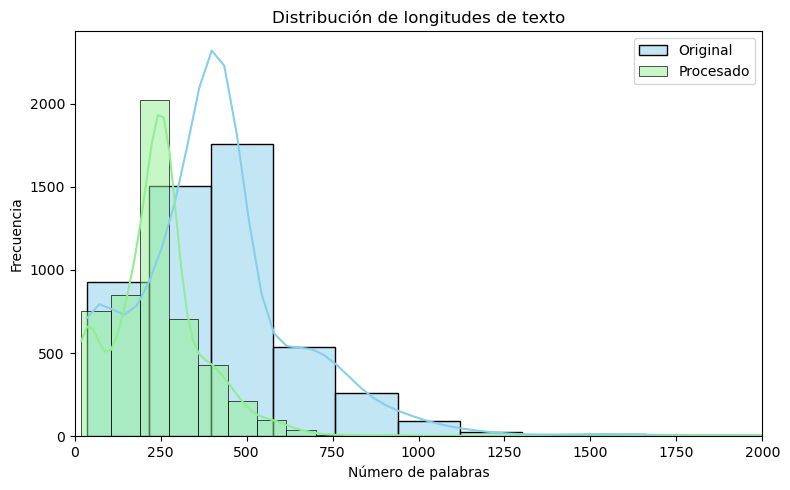

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df_valid['original_words'], bins=40, color='skyblue', alpha=0.5, label='Original', kde=True)
sns.histplot(df_valid['processed_words'], bins=40, color='lightgreen', alpha=0.5, label='Procesado', kde=True)
plt.xlim(0, 2000)
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitudes de texto')
plt.legend()
plt.tight_layout()
plt.show()

### MUESTRA FINAL DE RESULTADOS(3 FILAS)

In [24]:
output_path = "pruebasData/preprocNoContext.parquet"
df.to_parquet(output_path, index=False)

for idx in range(min(3, len(df_valid))):
    row = df_valid.iloc[idx]
    print(f"--- Fila {idx + 1} ---")
    print(f"Original ({int(row['original_words'])} palabras):")
    print(str(row["article_text"])[:150] + "...")
    print(f"\nProcesado ({int(row['processed_words'])} palabras):")
    print(str(row["noContextText"])[:150] + "...")
    print(f"\nReducción: {row['reduction_pct']:.1f}%\n")

--- Fila 1 ---
Original (370 palabras):
... UK jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month.

Procesado (191 palabras):
uk job market continue sign weakness pay growth slowing unemployment edge higher ahead autumn budget month late datum office national statistic ons re...

Reducción: 48.4%

--- Fila 2 ---
Original (454 palabras):
New data from the Department from Work and Pensions on the working patterns of people aged 50 and above showed that our working lives are getting ever...

Procesado (197 palabras):
new datum department work pension work pattern people age num work life long average age leave work rise trend isn people enthusiasm work it primarily...

Reducción: 56.6%

--- Fila 3 ---
Original (463 palabras):
Asking for workplace accommodations is often easier said than done. Many people worry about being seen as “needy” or “incompetent,” and as a result, c...

Procesado (239 palabr

Podemos ver que los resultados de estos ejemplos en concretos reducen un 50% el vocabulario, pero las palabras más claves (*market*, *growth*, *unemployment*, *ONS*) se mantienen y siguen teniendo coherencia del mismo tema, por lo que podemos confirmar que el pipeline ha sido efectivo.



### Resultado final

In [2]:
data = pd.read_parquet("datasPost_prepro/preprocNoContext.parquet")
data.head(5)

,ticker,headline,summary,article_text,topic,noContextText
0,AAPL,UK pay growth slows and unemployment ticks hig...,The UK jobs market continues to show signs of ...,The UK jobs market continues to show signs of ...,Financial and Market News and Corporate Sales,uk job market continue sign weakness pay growt...
1,AAPL,Rising pension age hits women hardest,Enabling people to work for longer can spell g...,New data from the Department from Work and Pen...,Informal / Conversational Lenguaje,new datum department work pension work pattern...
2,AAPL,How to ask for changes at work if you are neur...,Advocating for yourself can help create a cult...,Asking for workplace accommodations is often e...,Informal / Conversational Lenguaje,ask workplace accommodation easy people worry ...
3,AAPL,Apple announces major expansion of renewables ...,The tech giant has increased its involvement i...,Apple has announced a major expansion of its r...,Financial and Market News and Corporate Sales,apple announce major expansion renewable inves...
4,AAPL,"1 Unstoppable Stock Poised to Join Nvidia, App...",Semiconductors form the foundation of the arti...,The advent of artificial intelligence (AI) les...,Business Growth and Cloud Infrastructure in th...,advent artificial intelligence ai year ago spa...


## **PARA EMBEDDINGS NO CONTEXTUALES (Correción de entrega 2)**

Para corregir el error cometido en la segunda entrega (el usar lemmatization,... Para embeddings no contextuales cuando no es bueno), esta seccion es el arreglo. 

In [2]:
def preprocess_text_for_nc_embeddings_no_lemma(text: str) -> str:
    """
    Preprocesado para EMBEDDINGS NO CONTEXTUALES SIN LEMMATIZAR.
    - Usa pre_rules (normalización, placeholders, minúsculas, etc.).
    - NO usa lematización ni filtrado basado en lemma.
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # 1) Normalización + placeholders (igual que antes)
    t = pre_rules(text)
    if not t:
        return ""
    
    # 2) Tokenización sencilla con spaCy, pero SIN lematizar
    doc = nlp(t)
    tokens = []
    
    for tok in doc:
        text_tok = tok.text
        text_lower = text_tok.lower()
        
        # a) Preservar placeholders tal cual (__MONEY__, __PERCENT__...)
        if PLACEHOLDER_RE.match(text_tok):
            tokens.append(text_tok)
            continue
        
        # b) Saltar espacios y puntuación
        if tok.is_space or tok.is_punct:
            continue
        
        # c) Mantenemos las palabras tal cual (sin ir al lemma),
        #    pero en minúsculas para evitar duplicados raros
        if text_lower.isalpha() and len(text_lower) >= 3:
            tokens.append(text_lower)
            continue
        
        # d) Opcional: números normalizados (ya suelen venir como __NUM__)
        if text_lower.isdigit():
            tokens.append(text_lower)
            continue
    
    return " ".join(tokens)


In [11]:
# Creamos una versión del corpus pensada para entrenar embeddings no contextuales
df["ncEmbedText"] = df["article_text"].progress_apply(preprocess_text_for_nc_embeddings_no_lemma)

print("Corpus para embeddings no contextuales creado.")
print(f"Filas totales: {len(df)}")
print(f"Textos válidos: {df['ncEmbedText'].notna().sum()}")
print(f"Textos vacíos: {(df['ncEmbedText'].str.len() == 0).sum()}")


  0%|          | 0/5160 [00:00<?, ?it/s]

100%|██████████| 5160/5160 [03:40<00:00, 23.44it/s]

Corpus para embeddings no contextuales creado.
Filas totales: 5160
Textos válidos: 5160
Textos vacíos: 0


In [12]:
output_path_nc_emb = "datasPost_prepro/preprocNoContext_embeddings.parquet"
df[["article_text", "ncEmbedText"]].to_parquet(output_path_nc_emb, index=False)
print(f"Guardado corpus para embeddings no contextuales en: {output_path_nc_emb}")

Guardado corpus para embeddings no contextuales en: datasPost_prepro/preprocNoContext_embeddings.parquet


In [14]:
import pandas as pd

# Aseguramos que la columna que hemos creado existe
assert "ncEmbedText" in df.columns, "La columna 'ncEmbedText' no existe. Asegúrate de haber ejecutado el preprocesado sin lematizar."

df_stats = df.copy()

df_stats["original_words"] = df_stats["article_text"].apply(lambda x: len(str(x).split()))
df_stats["processed_words_nc"] = df_stats["ncEmbedText"].apply(lambda x: len(str(x).split()))
df_stats["reduction_pct_nc"] = 100 * (
    1 - (df_stats["processed_words_nc"] / df_stats["original_words"])
)

# Filtrar válidos (evitamos filas vacías)
df_valid_nc = df_stats[df_stats["processed_words_nc"] > 0]

print(f"Filas válidas procesadas (no contextuales): {len(df_valid_nc)}\n")

# -----------------------------
# 3) Mostrar ejemplos igual que antes
# -----------------------------
for idx in range(min(3, len(df_valid_nc))):
    row = df_valid_nc.iloc[idx]
    
    print(f"--- Fila {idx + 1} ---")
    
    print(f"Original ({int(row['original_words'])} palabras):")
    print(str(row["article_text"])[:150] + "...")
    
    print(f"\nProcesado (NO lematizado) ({int(row['processed_words_nc'])} palabras):")
    print(str(row["ncEmbedText"])[:150] + "...")
    
    print(f"\nReducción: {row['reduction_pct_nc']:.1f}%\n")


Filas válidas procesadas (no contextuales): 5160

--- Fila 1 ---
Original (370 palabras):
... UK jobs market continues to show signs of weakness, with pay growth slowing and unemployment edging higher ahead of the autumn budget next month.

Procesado (NO lematizado) (284 palabras):
the jobs market continues show signs weakness with pay growth slowing and unemployment edging higher ahead the autumn budget next month the latest dat...

Reducción: 23.2%

--- Fila 2 ---
Original (454 palabras):
New data from the Department from Work and Pensions on the working patterns of people aged 50 and above showed that our working lives are getting ever...

Procesado (NO lematizado) (337 palabras):
new data from the department from work and pensions the working patterns people aged num and above showed that our working lives are getting ever long...

Reducción: 25.8%

--- Fila 3 ---
Original (463 palabras):
Asking for workplace accommodations is often easier said than done. Many people worry about be

## **PARA EMBEDDINGS CONTEXTUALES**

En la creacion de *embeddings contextuales*, cada palabra obtiene un vector distinto según el contexto, por lo que necesitamos los textos lo más natural y completo posible para capturar el contexto, por lo que evitaremos practicas como la eliminación de stopwords, stemming o lemmatization.

### **BERT**

BERT (y la mayoría de los modelos basados en Transformer) utiliza una técnica de tokenización de subpalabras llamada WordPiece. Esta técnica es crucial para que el modelo funcione correctamente. Este tokenizador divide las palabras en subpalabras e inserta [CLS] (Clasificación/Inicio) al principio y [SEP] (Separador/Fin) al final de la secuencia. Mapea cada token (subpalabra) a su ID numérica correspondiente en el vocabulario de BERT, y rellena las secuencias cortas con el token [PAD], limitando las secuencias a 512 tokens.

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

inputs = tokenizer(
    textos,
    padding=True,          # Aplica relleno para que todas tengan la misma longitud.
    truncation=True,       # Trunca si exceden el max_length (512 por defecto).
    return_tensors='pt'    # Devuelve el resultado como tensores de PyTorch.
)
print("Ejemplo de tokenización BERT:")
print("Input IDs:", inputs['input_ids'][0])
print("Attention Mask:", inputs['attention_mask'][0])


c:\Users\Iñigo Peña\Desktop\FinTracker\ftenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ejemplo de tokenización BERT:
Input IDs: tensor([   101,  10117,  10523,  45083,  17313,  25266,  10114,  11897,  45033,
         10108,  61285,  14010,    117,  10169,  16868,  14609,  41573,  10230,
         10111,  10231, 108472,  10539,  13808,  17981,  35629,  10108,  10105,
         82240,  25293,  13451,  14064,    119,  10117,  50908,  11165,  10188,
         10105,  13348,  10142,  10655,  18499,    113,  49339,  10731,    114,
           117,  11539,  10135,  70245,    117,  27463,  10189,  19246,  11471,
         10525,  14609, 105376,  28215,  10171,  10106,  10105,  11003,  15555,
         10114,  10735,  10134,    125,    119,    128,    110,    117,  12935,
         31603,  10188,    125,    119,    129,    110,  10948,  10725,  10111,
         11112,    119,  10117,  10231, 108472,  18344,  13383,  10106,  10160,
           125,    119,    129,    110,  10142,  10105,  13127,    117,  31603,
         17981,  11084,  10105,    125,    119,    128,    110,  14227,  10142,

Cuando el tokenizer trunca los textos que superan el max_length (por defecto 512), se pierde información ,y por tanto, parte del contexto; ya que los modelos basados en Transformers (como BERT, FinBERT, NeuroBERT, etc.) fueron entrenados con una longitud máxima fija. Esto resultaria en un problema si los textos fuesen largos y tuviesen información relevante más allá del token 512, pero para muchas tareas, los fragmentos más relevantes suelen estar al inicio (titular, primeras frases), y en clasificación de noticias, o incluso NER en párrafos cortos, esto suele bastar.

In [ ]:
output_path = "datasPost_prepro/bertTokenized.parquet"
pd.DataFrame({
    'article_text': textos,
    'input_ids': inputs['input_ids'].tolist(),
    'attention_mask': inputs['attention_mask'].tolist()
}).to_parquet(output_path, index=False)

### Huggin Face **Fin-BERT**

En la estructura de nuestro proyecto, una de las tareas trata de extraer eventos o terminos financieros del texto, aplicando *Named Enity Recognition*. Para ello utilizaremos el modelos "boltuix/NeuroBERT-NER" que hemos encontrado en HuggingFace. Este modelo destaca por identificar 36 tipos de entidades (por ejemplo, personas, lugares, organizaciones, fechas, dinero) en texto en inglés, lo que lo hace ideal para la tarea de extracción de información.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
from torch.utils.data import DataLoader, Dataset
import pandas as pd

CHECKPOINT = "boltuix/NeuroBERT-NER"

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, use_fast=True)
model = AutoModel.from_pretrained(CHECKPOINT, output_hidden_states=True)


c:\Users\Iñigo Peña\Desktop\FinTracker\ftenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertModel were not initialized from the model checkpoint at boltuix/NeuroBERT-NER and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Este modelo Fin-BERT tiene su propio tokenizador, asique vamos a volver a procesar los textos para representarlos con el propio tokenizador del modelo. De igual manera, este modelo  mapea cada token a su ID numérica correspondiente en el vocabulario de BERT, y rellena las secuencias cortas con el token [PAD], limitando las secuencias a 512 tokens.

In [4]:
textos_split = [str(row["article_text"]).split() for _, row in df.iterrows()]
print(f"{textos_split[0][0:5]}...")
print(f"{textos_split[1][0:5]}...")
print(f"{textos_split[2][0:5]}...")

['The', 'UK', 'jobs', 'market', 'continues']...
['New', 'data', 'from', 'the', 'Department']...
['Asking', 'for', 'workplace', 'accommodations', 'is']...


In [5]:
all_input_ids = []
all_attention_masks = []

for words in textos_split:
    enc = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    input_id = enc['input_ids'][0]
    attention_mask = enc['attention_mask'][0]
    all_input_ids.append(input_id)
    all_attention_masks.append(attention_mask)
    
all_input_ids = torch.nn.utils.rnn.pad_sequence(all_input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
all_attention_masks = torch.nn.utils.rnn.pad_sequence(all_attention_masks, batch_first=True, padding_value=0)

print("all_input_ids shape:\n", all_input_ids.shape)
print("all_attention_masks shape\n:", all_attention_masks.shape)

all_input_ids shape:
 torch.Size([5160, 512])
all_attention_masks shape
: torch.Size([5160, 512])


#### **Visualización de los textos**

In [ ]:
output_path = "datasPost_prepro/fin-bertTokenized.parquet"
pd.DataFrame({
    'article_text': textos,
    'input_ids': all_input_ids.tolist(),
    'attention_mask': all_attention_masks.tolist()
}).to_parquet(output_path, index=False)

# Visualizamos las dimensiones de los tensores
print("Input IDs shape:", all_input_ids.shape)
print("Ejemplo Input ID:\n", all_input_ids[0][0:7], "...")
print("Attention Masks shape:", all_attention_masks.shape)
print("Ejemplo Attention Mask:\n", all_attention_masks[0][0:7], "...")


Input IDs shape: torch.Size([5160, 512])
Ejemplo Input ID:
 tensor([ 101, 1996, 2866, 5841, 3006, 4247, 2000]) ...
Attention Masks shape: torch.Size([5160, 512])
Ejemplo Attention Mask:
 tensor([1, 1, 1, 1, 1, 1, 1]) ...
